# GATE cumulative-feature ablation

Comparison of the original two-layer GAT and four-layer residual GAT. Features are cumulative from left to right. RMSE is pooled across all held-out model predictions; missing or incomplete runs remain missing rather than being assigned zero.

In [1]:
from pathlib import Path
import shutil

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams.update({
    "text.usetex": shutil.which("latex") is not None,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.frameon": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

candidates = [
    Path.cwd() / "node_feature_ablation_lr5e-6",
    Path.cwd() / "gate_run" / "node_feature_ablation_lr5e-6",
    Path.cwd(),
]
RUN_DIR = next((p.resolve() for p in candidates if any(p.glob("gat2_*/loss_history.csv"))), None)
if RUN_DIR is None:
    raise FileNotFoundError("Could not locate node_feature_ablation_lr5e-6")
FIGURE_DIR = RUN_DIR / "analysis_figures"
FIGURE_DIR.mkdir(exist_ok=True)
print(f"Run directory: {RUN_DIR}")
print(f"LaTeX rendering: {mpl.rcParams['text.usetex']}")

Run directory: /scratch/PPI-graph_autoencoder/gate_run/node_feature_ablation_lr5e-6
LaTeX rendering: True


In [2]:
STAGES = [
    ("01_aa_type", "AA type"),
    ("02_plus_chain", "+ Chain"),
    ("03_plus_interface_nodes", "+ Interface\nnodes"),
    ("04_plus_rsasa_i", r"+ $r$SASA$_i$"),
    ("05_plus_interface_node_degree", "+ Interface-node\ndegree"),
    ("06_plus_voronoi_contact_area", "+ Voronoi\narea"),
]
ARCHITECTURES = [
    ("gat2", "2-layer GAT", "black"),
    ("gat4_residual", "4-layer residual GAT", "lightgray"),
]

prediction_frames = {}
history_frames = {}
records = []
for arch_key, arch_label, _ in ARCHITECTURES:
    for stage_index, (stage_key, stage_label) in enumerate(STAGES, start=1):
        run_name = f"{arch_key}_{stage_key}"
        run_dir = RUN_DIR / run_name
        prediction_path = run_dir / "test_predictions.csv"
        history_path = run_dir / "loss_history.csv"
        if history_path.is_file():
            history_frames[run_name] = pd.read_csv(history_path)
        if prediction_path.is_file():
            frame = pd.read_csv(prediction_path)
            prediction_frames[run_name] = frame
            error = frame["predicted_target"] - frame["true_target"]
            per_target_rmse = frame.assign(sq_error=error**2).groupby("target_id")["sq_error"].mean().pow(0.5)
            records.append({
                "architecture": arch_label, "architecture_key": arch_key,
                "stage": stage_index, "feature_case": stage_label, "run_name": run_name,
                "models": len(frame), "targets": frame["target_id"].nunique(),
                "RMSE": np.sqrt(np.mean(error**2)), "MAE": np.mean(np.abs(error)),
                "mean_target_RMSE": per_target_rmse.mean(),
                "Pearson_r": frame["true_target"].corr(frame["predicted_target"]),
                "Spearman_rho": frame["true_target"].corr(frame["predicted_target"], method="spearman"),
                "status": "complete",
            })
        else:
            records.append({
                "architecture": arch_label, "architecture_key": arch_key,
                "stage": stage_index, "feature_case": stage_label, "run_name": run_name,
                "models": 0, "targets": 0, "RMSE": np.nan, "MAE": np.nan,
                "mean_target_RMSE": np.nan, "Pearson_r": np.nan, "Spearman_rho": np.nan,
                "status": "incomplete: no test_predictions.csv",
            })
metrics = pd.DataFrame(records)
display(metrics.drop(columns=["architecture_key", "run_name"]).style.format({
    "RMSE": "{:.4f}", "MAE": "{:.4f}", "mean_target_RMSE": "{:.4f}",
    "Pearson_r": "{:.4f}", "Spearman_rho": "{:.4f}",
}, na_rep="---"))

,architecture,stage,feature_case,models,targets,RMSE,MAE,mean_target_RMSE,Pearson_r,Spearman_rho,status
0,2-layer GAT,1,AA type,3044,25,0.3105,0.2754,0.3077,0.0485,0.0516,complete
1,2-layer GAT,2,+ Chain,3044,25,0.3097,0.2748,0.3069,0.1675,0.1797,complete
2,2-layer GAT,3,+ Interface nodes,3044,25,0.2978,0.2644,0.2953,0.4174,0.4153,complete
3,2-layer GAT,4,+ $r$SASA$_i$,3044,25,0.2631,0.2258,0.2577,0.5474,0.5815,complete
4,2-layer GAT,5,+ Interface-node degree,3044,25,0.2740,0.2172,0.2681,0.5067,0.5203,complete
5,2-layer GAT,6,+ Voronoi area,3044,25,0.2812,0.2231,0.2759,0.4806,0.4970,complete
6,4-layer residual GAT,1,AA type,3044,25,0.3116,0.2733,0.3086,0.0138,0.0296,complete
7,4-layer residual GAT,2,+ Chain,0,0,---,---,---,---,---,incomplete: no test_predictions.csv
8,4-layer residual GAT,3,+ Interface nodes,3044,25,0.2842,0.2374,0.2805,0.4120,0.4424,complete
9,4-layer residual GAT,4,+ $r$SASA$_i$,3044,25,0.2613,0.2182,0.2533,0.5429,0.5547,complete


## Observed versus predicted DockQ for all test targets

Choose any completed ablation run below. All 25 panels use common axes, and each title reports the target sample count and Spearman rank correlation. The final loop also exports an equivalent PDF for every completed run.

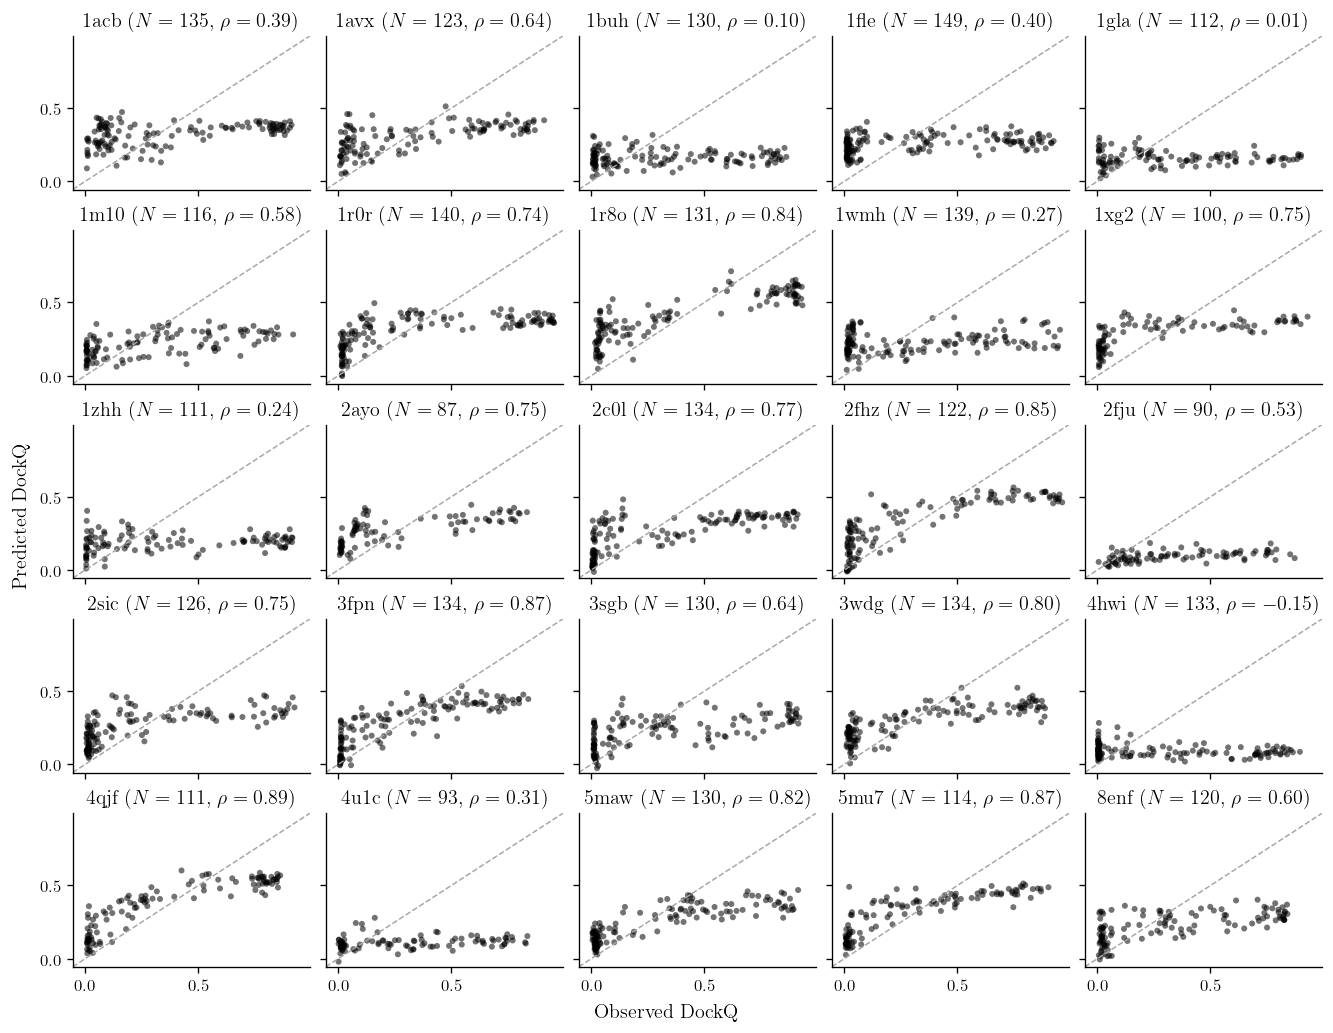

Exported 11 completed-run target panels to /scratch/PPI-graph_autoencoder/gate_run/node_feature_ablation_lr5e-6/analysis_figures


In [16]:
SELECTED_RUN = "gat4_residual_06_plus_voronoi_contact_area"

def plot_predictions_by_target(run_name, *, save=True, show=True):
    if run_name not in prediction_frames:
        available = "\n  ".join(sorted(prediction_frames))
        raise KeyError(f"No completed predictions for {run_name!r}. Available runs:\n  {available}")
    frame = prediction_frames[run_name]
    target_names = sorted(frame["target_id"].unique())
    ncols = 5
    nrows = int(np.ceil(len(target_names) / ncols))
    axis_min = min(frame["true_target"].min(), frame["predicted_target"].min())
    axis_max = max(frame["true_target"].max(), frame["predicted_target"].max())
    padding = 0.03 * (axis_max - axis_min)
    limits = (axis_min - padding, axis_max + padding)

    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 1.7 * nrows), sharex=True, sharey=True, constrained_layout=True)
    for ax, target_id in zip(np.atleast_1d(axes).flat, target_names):
        target = frame.loc[frame["target_id"] == target_id]
        rho = target["true_target"].corr(target["predicted_target"], method="spearman")
        ax.scatter(target["true_target"], target["predicted_target"], s=13, alpha=0.55, color="black", edgecolors="none")
        ax.plot(limits, limits, color="0.65", ls="--", lw=0.9)
        ax.set(xlim=limits, ylim=limits, title=rf"{target_id}  ($N={len(target)}$, $\rho={rho:.2f}$)")
    for ax in list(np.atleast_1d(axes).flat)[len(target_names):]:
        ax.set_visible(False)
    fig.supxlabel("Observed DockQ")
    fig.supylabel("Predicted DockQ")
    # fig.suptitle(run_name.replace("_", r"\_"), fontsize=14)
    if save:
        fig.savefig(FIGURE_DIR / f"dockq_by_target_{run_name}.pdf")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig

plot_predictions_by_target(SELECTED_RUN)

for run_name in sorted(prediction_frames):
    if run_name != SELECTED_RUN:
        plot_predictions_by_target(run_name, save=True, show=False)
print(f"Exported {len(prediction_frames)} completed-run target panels to {FIGURE_DIR}")

## DockQ RMSE across the cumulative ablation

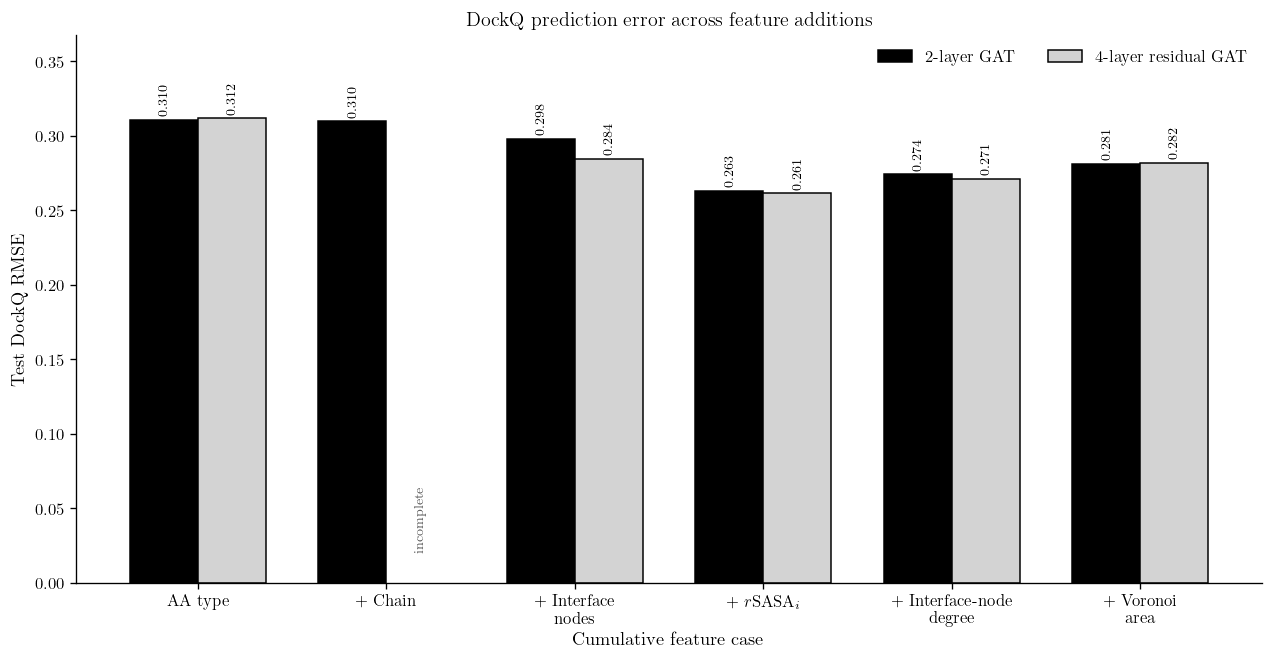

In [4]:
x = np.arange(len(STAGES))
width = 0.36
fig, ax = plt.subplots(figsize=(10.5, 5.4), constrained_layout=True)
for arch_index, (arch_key, arch_label, color) in enumerate(ARCHITECTURES):
    subset = metrics.loc[metrics["architecture_key"] == arch_key].sort_values("stage")
    positions = x + (arch_index - 0.5) * width
    bars = ax.bar(positions, subset["RMSE"], width, color=color, edgecolor="black", linewidth=0.9, label=arch_label)
    for position, value, status in zip(positions, subset["RMSE"], subset["status"]):
        if np.isfinite(value):
            ax.text(position, value + 0.0025, f"{value:.3f}", ha="center", va="bottom", fontsize=8, rotation=90)
        else:
            ax.text(position, 0.02, "incomplete", ha="center", va="bottom", fontsize=8, rotation=90, color="0.35")
ax.set_xticks(x, [label for _, label in STAGES])
ax.set(xlabel="Cumulative feature case", ylabel="Test DockQ RMSE", title="DockQ prediction error across feature additions", ylim=(0, metrics["RMSE"].max() * 1.18))
ax.legend(ncol=2, loc="upper right")
fig.savefig(FIGURE_DIR / "ablation_dockq_rmse.pdf")
plt.show()

## Rank correlation

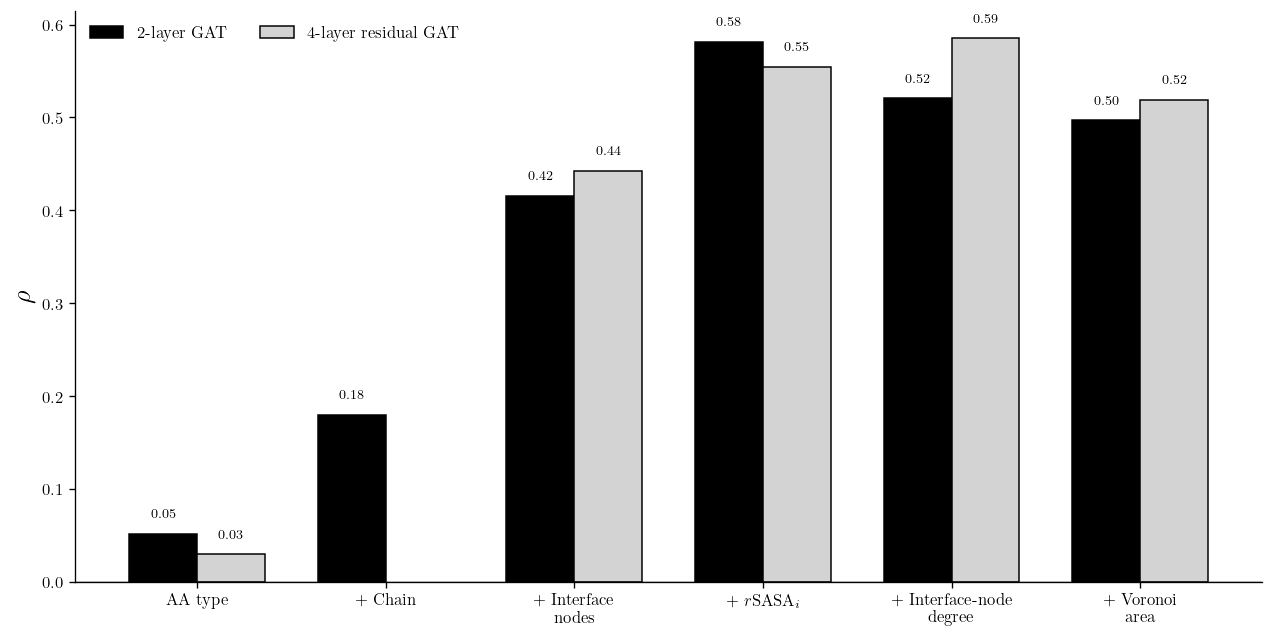

In [11]:
fig, ax = plt.subplots(figsize=(10.5, 5.2), constrained_layout=True)
for arch_index, (arch_key, arch_label, color) in enumerate(ARCHITECTURES):
    subset = metrics.loc[metrics["architecture_key"] == arch_key].sort_values("stage")
    positions = x + (arch_index - 0.5) * width
    ax.bar(positions, subset["Spearman_rho"], width, color=color, edgecolor="black", linewidth=0.9, label=arch_label)
    for position, value in zip(positions, subset["Spearman_rho"]):
        if np.isfinite(value):
            ax.text(position, value + 0.015, f"{value:.2f}", ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x, [label for _, label in STAGES])
ax.set_ylabel(r"$\rho$", fontsize = 16)
ax.legend(ncol=2, loc="upper left")
fig.savefig(FIGURE_DIR / "ablation_dockq_spearman.pdf")
plt.show()

## Incremental change from each added feature

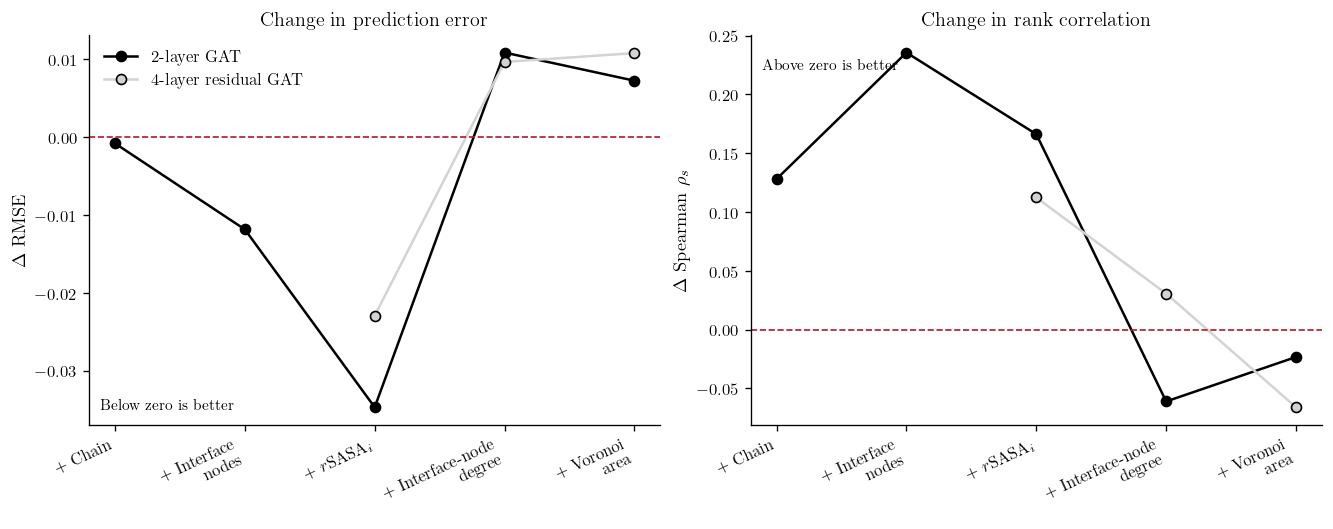

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True)
for arch_key, arch_label, color in ARCHITECTURES:
    subset = metrics.loc[metrics["architecture_key"] == arch_key].sort_values("stage")
    axes[0].plot(x, subset["RMSE"].diff(), marker="o", color=color, markeredgecolor="black", label=arch_label)
    axes[1].plot(x, subset["Spearman_rho"].diff(), marker="o", color=color, markeredgecolor="black", label=arch_label)
for ax in axes:
    ax.axhline(0, color="#b2182b", ls="--", lw=1)
    ax.set_xticks(x[1:], [label for _, label in STAGES][1:], rotation=25, ha="right")
axes[0].set(ylabel=r"$\Delta$ RMSE", title="Change in prediction error")
axes[1].set(ylabel=r"$\Delta$ Spearman $\rho_s$", title="Change in rank correlation")
axes[0].text(0.02, 0.04, "Below zero is better", transform=axes[0].transAxes, fontsize=9)
axes[1].text(0.02, 0.94, "Above zero is better", transform=axes[1].transAxes, va="top", fontsize=9)
axes[0].legend()
fig.savefig(FIGURE_DIR / "ablation_incremental_changes.pdf")
plt.show()

## Validation target-loss convergence

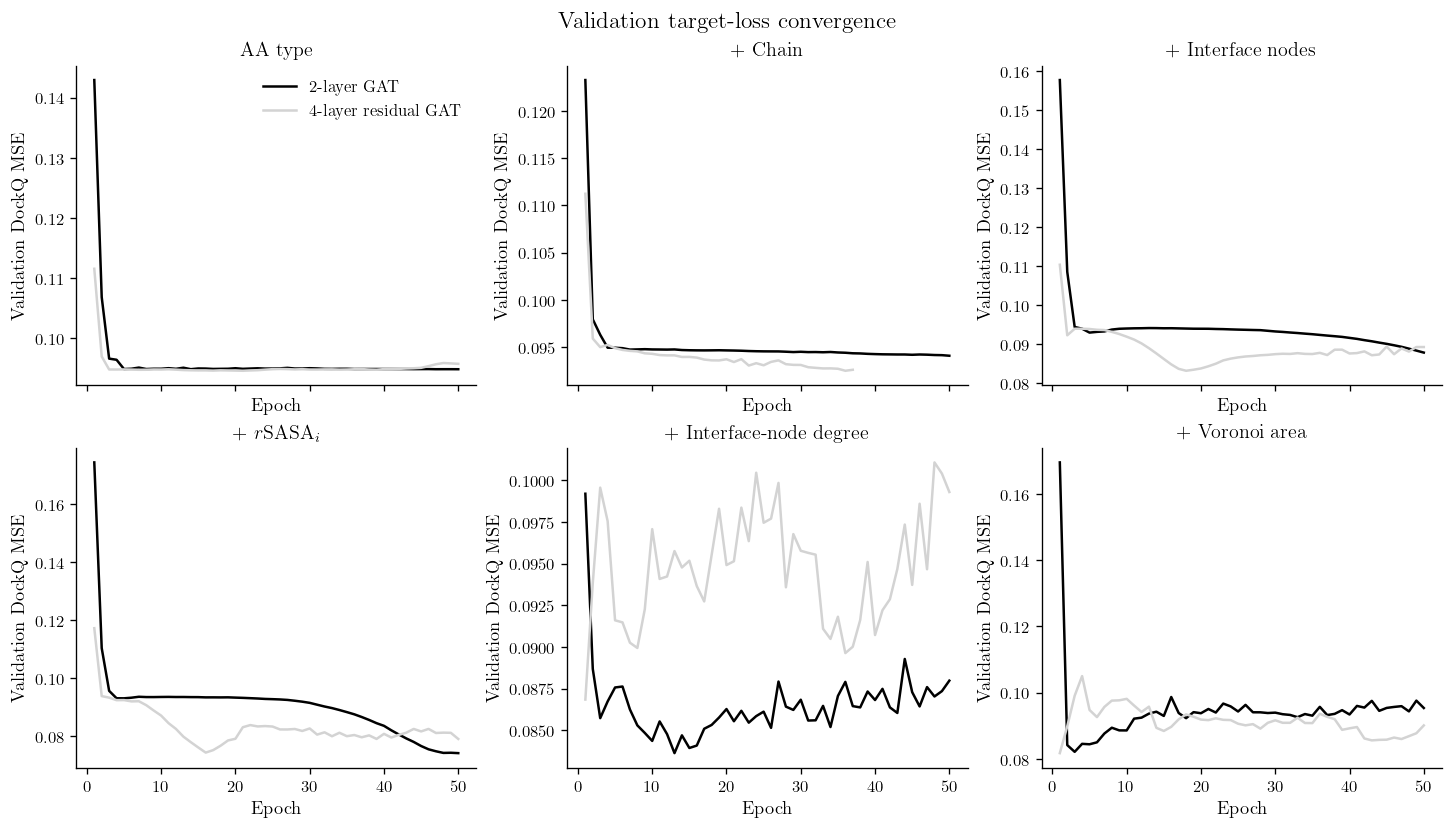

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6.8), sharex=True, constrained_layout=True)
for stage_index, ((stage_key, stage_label), ax) in enumerate(zip(STAGES, axes.flat), start=1):
    for arch_key, arch_label, color in ARCHITECTURES:
        run_name = f"{arch_key}_{stage_key}"
        if run_name not in history_frames:
            ax.text(0.5, 0.5, f"{arch_label} incomplete", transform=ax.transAxes, ha="center", color="0.35")
            continue
        history = history_frames[run_name]
        ax.plot(history["epoch"], history["val_target_mse"], color=color, lw=1.5, label=arch_label)
    ax.set(title=stage_label.replace("\n", " "), xlabel="Epoch", ylabel="Validation DockQ MSE")
axes[0, 0].legend()
fig.suptitle("Validation target-loss convergence", fontsize=14)
fig.savefig(FIGURE_DIR / "ablation_validation_target_mse.pdf")
plt.show()

## Target-level effect of adding Voronoi area

Each point is one held-out target. Values below the identity line improved after adding Voronoi area; values above it worsened.

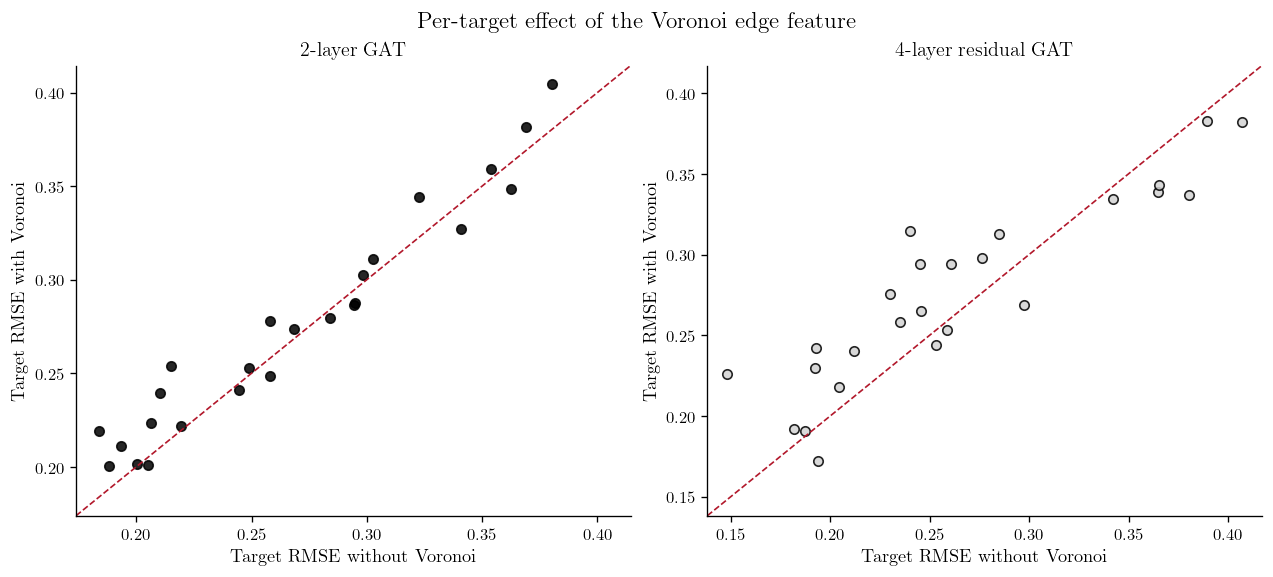

,architecture,mean_target_delta_RMSE,targets_improved,targets_total
0,2-layer GAT,+0.0078,8,25
1,4-layer residual GAT,+0.0127,10,25


In [8]:
def rmse_by_target(frame):
    return frame.assign(sq_error=(frame["predicted_target"] - frame["true_target"])**2).groupby("target_id")["sq_error"].mean().pow(0.5)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.7), constrained_layout=True)
voronoi_effect_rows = []
for ax, (arch_key, arch_label, color) in zip(axes, ARCHITECTURES):
    before = rmse_by_target(prediction_frames[f"{arch_key}_05_plus_interface_node_degree"])
    after = rmse_by_target(prediction_frames[f"{arch_key}_06_plus_voronoi_contact_area"])
    paired = pd.concat({"Without Voronoi": before, "With Voronoi": after}, axis=1).dropna()
    limits = [paired.to_numpy().min() - 0.01, paired.to_numpy().max() + 0.01]
    ax.scatter(paired["Without Voronoi"], paired["With Voronoi"], color=color, edgecolor="black", s=32, alpha=0.85)
    ax.plot(limits, limits, color="#b2182b", ls="--", lw=1)
    ax.set(xlim=limits, ylim=limits, xlabel="Target RMSE without Voronoi", ylabel="Target RMSE with Voronoi", title=arch_label)
    differences = paired["With Voronoi"] - paired["Without Voronoi"]
    voronoi_effect_rows.append({"architecture": arch_label, "mean_target_delta_RMSE": differences.mean(), "targets_improved": int((differences < 0).sum()), "targets_total": len(differences)})
fig.suptitle("Per-target effect of the Voronoi edge feature", fontsize=14)
fig.savefig(FIGURE_DIR / "voronoi_target_rmse_comparison.pdf")
plt.show()
display(pd.DataFrame(voronoi_effect_rows).style.format({"mean_target_delta_RMSE": "{:+.4f}"}))

## Reading the plots

- Lower RMSE and higher Spearman correlation are better.
- The incremental panels isolate the change at each cumulative step, although each model was trained independently.
- The final paired-target plot is the most direct view of whether Voronoi area helps consistently or only for particular targets.
- Array task 8 (`gat4_residual_02_plus_chain`) is treated as incomplete until it has a `test_predictions.csv`.
- Figures are saved as PDFs under `node_feature_ablation_lr5e-6/analysis_figures/`.